
# Member 1 — Dataset Understanding & Data Quality Analysis

## Objectives
- Understand dataset structure
- Inspect dataset quality
- Handle missing values
- Analyze duplicates


In [202]:
import pandas as pd

# Load dataset
# Keep the Excel file inside the "Data set" folder.
df = pd.read_excel('/content/dataset -P676 (1).xlsx')

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()


Dataset loaded successfully
Dataset shape: (1440, 3)


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


## Dataset Inspection

In [203]:

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


Dataset Shape: (1440, 3)

Columns:
Index(['title', 'rating', 'body'], dtype='object')

Data Types:
title     object
rating     int64
body      object
dtype: object


## Identified Important Columns

In [204]:

title_column = "title"
rating_column = "rating"
body_column = "body"

print("Title Column:", title_column)
print("Rating Column:", rating_column)
print("Body Column:", body_column)


Title Column: title
Rating Column: rating
Body Column: body


## Missing Value Analysis

In [205]:

missing_values = df.isnull().sum()
missing_values


,0
title,0
rating,0
body,0


## Duplicate Analysis

In [206]:

duplicate_rows = df.duplicated().sum()
print("Duplicate Rows:", duplicate_rows)

if "title" != "None":
    print("Duplicate Titles:", df["title"].duplicated().sum())

if "body" != "None":
    print("Duplicate Bodies:", df["body"].duplicated().sum())


Duplicate Rows: 0
Duplicate Titles: 89
Duplicate Bodies: 0


## Remove Duplicate Rows

In [207]:
df_no_duplicates = df.drop_duplicates()

print("Shape Before Removing Duplicates:", df.shape)
print("Shape After Removing Duplicates:", df_no_duplicates.shape)

Shape Before Removing Duplicates: (1440, 3)
Shape After Removing Duplicates: (1440, 3)


## Final Dataset Summary

In [208]:

print(df_no_duplicates.info())

df_no_duplicates.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB
None


,title,rating,body
count,1440,1440.000000,1440
unique,1351,NaN,1440
top,Value for money,NaN,Good phone for budget buyers. Sound quality is...
freq,16,NaN,1
mean,NaN,3.173611,NaN
std,NaN,1.584453,NaN
min,NaN,1.000000,NaN
25%,NaN,1.000000,NaN
50%,NaN,4.000000,NaN
75%,NaN,5.000000,NaN


# Member-2 Language Detection & Multilingual Analysis

## Objectives:

1. Language Detection
2. Language Distribution Analysis
3. Mixed-language Detection
4. Transliteration Detection


In [209]:
# Language detection setup
# Uses langdetect if available. If not available, uses a simple script-based fallback.
try:
    from langdetect import detect as langdetect_detect
    LANGDETECT_AVAILABLE = True
except Exception:
    langdetect_detect = None
    LANGDETECT_AVAILABLE = False

print("langdetect available:", LANGDETECT_AVAILABLE)

langdetect available: False


In [210]:
# Import required libraries for Part 2
import os
import pandas as pd
import matplotlib.pyplot as plt

In [211]:
# Part 2 starts from the cleaned dataset created in Member 1.
# No old/helper dataframe is used here.

df_processed = df_no_duplicates.copy()

print("Part 2 input dataframe: df_no_duplicates")
print("df_processed shape:", df_processed.shape)

df_processed.head()


Part 2 input dataframe: df_no_duplicates
df_processed shape: (1440, 3)


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


# Create Language Detection Function

In [212]:
def detect_language(text):
    """Detect language safely.

    If langdetect is installed, it uses langdetect.
    Otherwise, it uses a fallback based on Unicode script ranges.
    """
    text = '' if pd.isna(text) else str(text).strip()

    if text == '':
        return 'unknown'

    # Fallback checks for Indian language scripts
    has_devanagari = any('\u0900' <= char <= '\u097F' for char in text)
    has_telugu = any('\u0C00' <= char <= '\u0C7F' for char in text)
    has_tamil = any('\u0B80' <= char <= '\u0BFF' for char in text)

    if has_telugu:
        return 'te'
    if has_tamil:
        return 'ta'
    if has_devanagari:
        return 'hi'

    # Use langdetect only if available
    if LANGDETECT_AVAILABLE:
        try:
            return langdetect_detect(text)
        except Exception:
            return 'unknown'

    # Basic English fallback
    has_english = any(('a' <= char.lower() <= 'z') for char in text)
    if has_english:
        return 'en'

    return 'unknown'

# Apply Language Detection

In [213]:
# Apply language detection on the same df_processed dataframe.
# body_cleaned is created here only for Part 2 compatibility.

if 'body_cleaned' not in df_processed.columns:
    df_processed['body_cleaned'] = df_processed['body'].fillna('').astype(str)

if 'title_cleaned' not in df_processed.columns and 'title' in df_processed.columns:
    df_processed['title_cleaned'] = df_processed['title'].fillna('').astype(str)

# Detect language from cleaned body text
df_processed['language_code'] = df_processed['body_cleaned'].apply(detect_language)

print("Language detection completed")
print("df_processed shape:", df_processed.shape)

df_processed[['body_cleaned', 'language_code']].head(10)


Language detection completed
df_processed shape: (1440, 6)


,body_cleaned,language_code
0,Very disappointed with the overall performance...,en
1,Camera quality is low,en
2,"Got the mobile on the launch date,Battery must...",en
3,1. It doesn't work with 5.0GHz WiFi frequency....,en
4,"Not worth buying....faulty software, poor disp...",en
5,I will never purchase Samsung phones. Phone is...,en
6,This is worst samsung mobile I have seen from ...,en
7,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...,hi
8,The phone hangs a lot and is very slow. I rece...,en
9,Very poor quality camera .Found box seal damag...,en


# Check Output

In [214]:
df_processed[['body_cleaned', 'language_code']].head(10)

,body_cleaned,language_code
0,Very disappointed with the overall performance...,en
1,Camera quality is low,en
2,"Got the mobile on the launch date,Battery must...",en
3,1. It doesn't work with 5.0GHz WiFi frequency....,en
4,"Not worth buying....faulty software, poor disp...",en
5,I will never purchase Samsung phones. Phone is...,en
6,This is worst samsung mobile I have seen from ...,en
7,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...,hi
8,The phone hangs a lot and is very slow. I rece...,en
9,Very poor quality camera .Found box seal damag...,en


# Convert Language Codes

In [215]:
language_map = {
    'en': 'English',
    'hi': 'Hindi',
    'ta': 'Tamil',
    'te': 'Telugu',
    'kn': 'Kannada',
    'ml': 'Malayalam',
    'mr': 'Marathi',
    'bn': 'Bengali',
    'gu': 'Gujarati',
    'unknown': 'Unknown'
}

# Keep both columns:
# language_code -> raw langdetect output like en, hi, ta
# language      -> readable name like English, Hindi, Tamil
df_processed['language'] = df_processed['language_code'].map(language_map).fillna('Other')

df_processed[['body_cleaned', 'language_code', 'language']].head(10)

,body_cleaned,language_code,language
0,Very disappointed with the overall performance...,en,English
1,Camera quality is low,en,English
2,"Got the mobile on the launch date,Battery must...",en,English
3,1. It doesn't work with 5.0GHz WiFi frequency....,en,English
4,"Not worth buying....faulty software, poor disp...",en,English
5,I will never purchase Samsung phones. Phone is...,en,English
6,This is worst samsung mobile I have seen from ...,en,English
7,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...,hi,Hindi
8,The phone hangs a lot and is very slow. I rece...,en,English
9,Very poor quality camera .Found box seal damag...,en,English


In [216]:
df_processed[['body_cleaned', 'language_code', 'language']].head(10)

,body_cleaned,language_code,language
0,Very disappointed with the overall performance...,en,English
1,Camera quality is low,en,English
2,"Got the mobile on the launch date,Battery must...",en,English
3,1. It doesn't work with 5.0GHz WiFi frequency....,en,English
4,"Not worth buying....faulty software, poor disp...",en,English
5,I will never purchase Samsung phones. Phone is...,en,English
6,This is worst samsung mobile I have seen from ...,en,English
7,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...,hi,Hindi
8,The phone hangs a lot and is very slow. I rece...,en,English
9,Very poor quality camera .Found box seal damag...,en,English


# Language Distribution Analysis

In [217]:
# Re-check / refresh language detection safely without overwriting readable language names
# This avoids the earlier issue where language names were replaced again by raw codes.

df_processed['language_code'] = df_processed['body_cleaned'].fillna('').astype(str).apply(detect_language)
df_processed['language'] = df_processed['language_code'].map(language_map).fillna('Other')

df_processed[['body_cleaned', 'language_code', 'language']].head(10)

,body_cleaned,language_code,language
0,Very disappointed with the overall performance...,en,English
1,Camera quality is low,en,English
2,"Got the mobile on the launch date,Battery must...",en,English
3,1. It doesn't work with 5.0GHz WiFi frequency....,en,English
4,"Not worth buying....faulty software, poor disp...",en,English
5,I will never purchase Samsung phones. Phone is...,en,English
6,This is worst samsung mobile I have seen from ...,en,English
7,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...,hi,Hindi
8,The phone hangs a lot and is very slow. I rece...,en,English
9,Very poor quality camera .Found box seal damag...,en,English


In [218]:
language_percentage = (
    df_processed['language']
    .value_counts(normalize=True) * 100
).round(2)

print(language_percentage)

language
English    99.17
Hindi       0.83
Name: proportion, dtype: float64


In [219]:
print(df_processed['language'].unique())

['English' 'Hindi']


## Check language counts



In [220]:
print(df_processed['language'].value_counts())

language
English    1428
Hindi        12
Name: count, dtype: int64


## DOMINANT LANGUAGE

In [221]:
dominant_language = df_processed['language'].mode()[0]

print("\nDominant Language:")
print(dominant_language)


Dominant Language:
English


## LANGUAGE DISTRIBUTION
### CHART


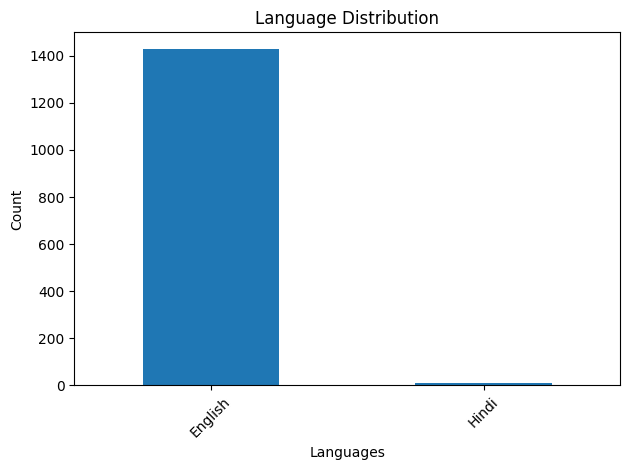

In [222]:
df_processed['language'].value_counts().plot(kind='bar')

plt.title("Language Distribution")
plt.xlabel("Languages")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## MIXED LANGUAGE
### DETECTION


In [223]:
def detect_mixed_language(text):
    text = '' if pd.isna(text) else str(text)

    has_english = any(ord(char) < 128 and char.isalpha() for char in text)
    has_devanagari = any('\u0900' <= char <= '\u097F' for char in text)
    has_telugu = any('\u0C00' <= char <= '\u0C7F' for char in text)
    has_tamil = any('\u0B80' <= char <= '\u0BFF' for char in text)

    if has_english and (has_devanagari or has_telugu or has_tamil):
        return 'Mixed'

    return 'Single'


df_processed['mixed_language'] = df_processed['body_cleaned'].apply(detect_mixed_language)

print("\nMixed Language Statistics:")
print(df_processed['mixed_language'].value_counts())


Mixed Language Statistics:
mixed_language
Single    1431
Mixed        9
Name: count, dtype: int64


 ## TRANSLITERATION
### DETECTION

In [224]:
transliterated_words = [
    'bahut', 'accha', 'acha', 'mast', 'undhi', 'undi', 'bagundi',
    'bekar', 'kharab', 'paisa', 'kaam', 'nahi', 'hai'
]


def transliteration_detection(text):
    text = '' if pd.isna(text) else str(text).lower()

    for word in transliterated_words:
        if word in text:
            return 'Yes'

    return 'No'


df_processed['transliteration'] = df_processed['body_cleaned'].apply(transliteration_detection)

print("\nTransliteration Statistics:")
print(df_processed['transliteration'].value_counts())


Transliteration Statistics:
transliteration
No     1413
Yes      27
Name: count, dtype: int64


##  OUTPUT

In [225]:
output_columns = ['body', 'body_cleaned', 'language_code', 'language', 'mixed_language', 'transliteration']
output_columns = [col for col in output_columns if col in df_processed.columns]

df_processed[output_columns].head(10)

,body,body_cleaned,language_code,language,mixed_language,transliteration
0,Very disappointed with the overall performance...,Very disappointed with the overall performance...,en,English,Single,No
1,Camera quality is low,Camera quality is low,en,English,Single,No
2,"Got the mobile on the launch date,Battery must...","Got the mobile on the launch date,Battery must...",en,English,Single,No
3,1. It doesn't work with 5.0GHz WiFi frequency....,1. It doesn't work with 5.0GHz WiFi frequency....,en,English,Single,No
4,"Not worth buying....faulty software, poor disp...","Not worth buying....faulty software, poor disp...",en,English,Single,No
5,I will never purchase Samsung phones. Phone is...,I will never purchase Samsung phones. Phone is...,en,English,Single,No
6,This is worst samsung mobile I have seen from ...,This is worst samsung mobile I have seen from ...,en,English,Single,No
7,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...,hi,Hindi,Mixed,No
8,The phone hangs a lot and is very slow. I rece...,The phone hangs a lot and is very slow. I rece...,en,English,Single,No
9,Very poor quality camera .Found box seal damag...,Very poor quality camera .Found box seal damag...,en,English,Single,No


## FINAL REPORT

In [226]:
df_processed.to_csv(
    "language_analysis_report.csv",
    index=False,
    encoding='utf-8-sig'
)

print("\nFinal Part 2 language analysis report saved successfully: language_analysis_report.csv")


Final Part 2 language analysis report saved successfully: language_analysis_report.csv


# Member 3 - Encoding, Cleaning & Preprocessing

## Objectives:
1. Check required columns
2. Check broken/unreadable characters
3. Normalize and clean multilingual text
4. Combine cleaned title and body into one review text

From this section onward, we use one common dataframe: `df_processed`.

Flow:

`df_no_duplicates → df_processed → Member 4 → Member 5 → Member 6`


In [227]:
# Import libraries for text cleaning

import re
import unicodedata
import pandas as pd
from bs4 import BeautifulSoup

In [228]:
# Start Member 3 from cleaned data

df_processed = df_no_duplicates.copy()

df_processed.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [229]:
# Check required columns for Member 3

required_columns = ['title', 'body', 'rating']

missing_columns = [col for col in required_columns if col not in df_processed.columns]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are available")

All required columns are available


In [230]:
# Check broken characters in title and body

def has_broken_characters(text):
    text = '' if pd.isna(text) else str(text)
    return any(char in text for char in ['�', 'Ã', 'Â', 'â', '???'])

print("Broken title rows:", df_processed['title'].apply(has_broken_characters).sum())
print("Broken body rows:", df_processed['body'].apply(has_broken_characters).sum())

Broken title rows: 0
Broken body rows: 2


In [231]:
# Function to normalize Unicode text into a consistent form
# Unicode normalization helps maintain proper representation of multilingual scripts
# such as Hindi, Telugu, Tamil, and English mixed text

def normalize_unicode(text):
    # Convert missing values to an empty string
    text = '' if pd.isna(text) else str(text)

    # NFKC standardizes visually similar Unicode characters into a consistent form
    normalized_text = unicodedata.normalize('NFKC', text)

    # Return normalized text
    return normalized_text


In [232]:
# Function to clean multilingual text while preserving Hindi, Telugu, and Tamil scripts
# This function removes noise but keeps useful multilingual review content
def clean_multilingual_text(text):

    # Normalize text to fix Unicode issues
    text = normalize_unicode(text)

    # Remove HTML tags
    text = BeautifulSoup(text, 'html.parser').get_text(' ')

    # Remove website links
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Convert English text to lowercase
    text = text.lower()

    # Remove symbols but keep English, Hindi, Telugu, and Tamil text
    text = re.sub(r'[^a-zA-Z0-9\sऀ-ॿఀ-౿஀-௿]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [233]:
# Apply cleaning on title and body

df_processed['clean_title'] = df_processed['title'].apply(clean_multilingual_text)
df_processed['clean_body'] = df_processed['body'].apply(clean_multilingual_text)

# Check original and cleaned text
df_processed[['title', 'clean_title', 'body', 'clean_body']].head()

,title,clean_title,body,clean_body
0,Horrible product,horrible product,Very disappointed with the overall performance...,very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,camera quality is not like 48 megapixel,Camera quality is low,camera quality is low
2,Overall,overall,"Got the mobile on the launch date,Battery must...",got the mobile on the launch date battery must...
3,A big no from me,a big no from me,1. It doesn't work with 5.0GHz WiFi frequency....,1 it doesn t work with 5 0ghz wifi frequency 2...
4,Put your money somewhere else,put your money somewhere else,"Not worth buying....faulty software, poor disp...",not worth buying faulty software poor display ...


In [234]:
# Combine cleaned title and body into one review text

df_processed['review_text'] = (
    df_processed['clean_title'] + ' ' + df_processed['clean_body']
).str.strip()

# Remove extra spaces
df_processed['review_text'] = df_processed['review_text'].str.replace(r'\s+', ' ', regex=True)

# Preview combined text
df_processed[['clean_title', 'clean_body', 'review_text']].head()

,clean_title,clean_body,review_text
0,horrible product,very disappointed with the overall performance...,horrible product very disappointed with the ov...
1,camera quality is not like 48 megapixel,camera quality is low,camera quality is not like 48 megapixel camera...
2,overall,got the mobile on the launch date battery must...,overall got the mobile on the launch date batt...
3,a big no from me,1 it doesn t work with 5 0ghz wifi frequency 2...,a big no from me 1 it doesn t work with 5 0ghz...
4,put your money somewhere else,not worth buying faulty software poor display ...,put your money somewhere else not worth buying...


In [235]:
# Final check and column mapping after Member 3 cleaning

empty_review_count = (df_processed['review_text'] == '').sum()

df_processed['title_cleaned'] = df_processed['clean_title']
df_processed['body_cleaned'] = df_processed['clean_body']
df_processed['final_review_text'] = df_processed['review_text']

print("Member 3 completed")
print("Final rows:", len(df_processed))
print("Final columns:", df_processed.shape[1])
print("Empty review_text rows:", empty_review_count)

Member 3 completed
Final rows: 1440
Final columns: 9
Empty review_text rows: 0


## Member 3 Conclusion

Member 3 cleaned the `title` and `body` text, handled Unicode normalization, removed noise like HTML tags, URLs, symbols, and extra spaces, and created one combined cleaned column: `review_text`.

At the end of Member 3, the cleaned columns are mapped into standard names so the next members can continue with the same `df_processed` dataframe.


# Master DataFrame Alignment for Members 4, 5 and 6

From this point onward, the notebook uses **one common dataframe: `df_processed`**.

This avoids the earlier issue where later members were using old dataframe names like `df`, `cleaned_df`, `df_no_duplicates`, or `df_member3` directly.

Final flow:

**Raw dataset → Member 1 cleaning → Member 3 preprocessing → `df_processed` → Member 4 → Member 5 → Member 6**


In [236]:
# Final alignment for Members 4, 5, and 6

df_processed['title_cleaned'] = df_processed['clean_title']
df_processed['body_cleaned'] = df_processed['clean_body']
df_processed['final_review_text'] = df_processed['review_text']

df_processed['sentiment'] = df_processed['rating'].apply(
    lambda x: 'positive' if x >= 4 else 'neutral' if x == 3 else 'negative'
)

print("df_processed ready for Members 4, 5, and 6")
print("Shape:", df_processed.shape)

df_processed[['title_cleaned', 'body_cleaned', 'final_review_text', 'sentiment']].head()

df_processed ready for Members 4, 5, and 6
Shape: (1440, 10)


,title_cleaned,body_cleaned,final_review_text,sentiment
0,horrible product,very disappointed with the overall performance...,horrible product very disappointed with the ov...,negative
1,camera quality is not like 48 megapixel,camera quality is low,camera quality is not like 48 megapixel camera...,neutral
2,overall,got the mobile on the launch date battery must...,overall got the mobile on the launch date batt...,positive
3,a big no from me,1 it doesn t work with 5 0ghz wifi frequency 2...,a big no from me 1 it doesn t work with 5 0ghz...,negative
4,put your money somewhere else,not worth buying faulty software poor display ...,put your money somewhere else not worth buying...,negative


#Member 4 — Tokenization, Stopwords & Lemmatization

## Objectives:
1. Language-wise Tokenization
2. Language-specific Stopword Removal
3. Stemming
4. Lemmatization

### Tokenization

Tokenization is the process of breaking a stream of text into words, phrases, symbols, or other meaningful elements called tokens. These tokens are then used as input for further processing.

In [237]:
# Tokenization on cleaned review text

import re

# Function to split text into words
def tokenize_text(text):
    text = '' if pd.isna(text) else str(text)
    return re.findall(r'\b\w+\b', text)

# Apply tokenization on cleaned columns
df_processed['title_tokens'] = df_processed['title_cleaned'].apply(tokenize_text)
df_processed['body_tokens'] = df_processed['body_cleaned'].apply(tokenize_text)
df_processed['review_tokens'] = df_processed['final_review_text'].apply(tokenize_text)

# Preview tokens
df_processed[['final_review_text', 'review_tokens']].head()


,final_review_text,review_tokens
0,horrible product very disappointed with the ov...,"[horrible, product, very, disappointed, with, ..."
1,camera quality is not like 48 megapixel camera...,"[camera, quality, is, not, like, 48, megapixel..."
2,overall got the mobile on the launch date batt...,"[overall, got, the, mobile, on, the, launch, d..."
3,a big no from me 1 it doesn t work with 5 0ghz...,"[a, big, no, from, me, 1, it, doesn, t, work, ..."
4,put your money somewhere else not worth buying...,"[put, your, money, somewhere, else, not, worth..."


### Removing Stop Words

Stop words are common words (like 'the', 'is', 'and') that often carry little meaning in text analysis and can be removed to reduce noise and improve processing efficiency. We will use NLTK's list of English stop words.

In [238]:
# Stopword removal without internet dependency
# Uses the token columns created from the updated df_processed dataframe.

try:
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))
except Exception:
    # Basic fallback stopword list if NLTK stopwords are unavailable
    stop_words = {
        'a', 'an', 'the', 'and', 'or', 'but', 'if', 'is', 'are', 'was', 'were',
        'to', 'of', 'in', 'on', 'for', 'with', 'this', 'that', 'it', 'as', 'at',
        'by', 'from', 'be', 'been', 'am', 'i', 'you', 'he', 'she', 'they', 'we'
    }

# Keep important negation words because they affect sentiment
negation_words = {'not', 'no', 'nor', 'never'}
stop_words = stop_words - negation_words


def remove_stopwords(tokens):
    return [str(word).lower() for word in tokens if str(word).lower() not in stop_words]

# Apply stopword removal on updated token columns
df_processed['title_tokens_cleaned'] = df_processed['title_tokens'].apply(remove_stopwords)
df_processed['body_tokens_cleaned'] = df_processed['body_tokens'].apply(remove_stopwords)
df_processed['review_tokens_cleaned'] = df_processed['review_tokens'].apply(remove_stopwords)

# Display sample cleaned tokens
display(df_processed[['title_tokens_cleaned', 'body_tokens_cleaned', 'review_tokens_cleaned']].head())


,title_tokens_cleaned,body_tokens_cleaned,review_tokens_cleaned
0,"[horrible, product]","[very, disappointed, overall, performance, sam...","[horrible, product, very, disappointed, overal..."
1,"[camera, quality, not, like, 48, megapixel]","[camera, quality, low]","[camera, quality, not, like, 48, megapixel, ca..."
2,[overall],"[got, mobile, launch, date, battery, must, app...","[overall, got, mobile, launch, date, battery, ..."
3,"[big, no, me]","[1, doesn, t, work, 5, 0ghz, wifi, frequency, ...","[big, no, me, 1, doesn, t, work, 5, 0ghz, wifi..."
4,"[put, your, money, somewhere, else]","[not, worth, buying, faulty, software, poor, d...","[put, your, money, somewhere, else, not, worth..."


### Lemmatization

Lemmatization is the process of grouping together the inflected forms of a word so they can be analyzed as a single item, identified by the word's lemma or dictionary form. For example, 'running', 'runs', and 'ran' would all be lemmatized to 'run'. This helps reduce the sparsity of the data and improves the efficiency and accuracy of text analysis tasks.

In [239]:
# Lemmatization without internet dependency
# Uses the cleaned token columns from df_processed.

try:
    from nltk.stem import WordNetLemmatizer
    lemmatizer = WordNetLemmatizer()
except Exception:
    lemmatizer = None


def lemmatize_tokens(tokens):
    if lemmatizer is None:
        return [str(word) for word in tokens]

    try:
        return [lemmatizer.lemmatize(str(word)) for word in tokens]
    except Exception:
        # If WordNet data is unavailable, keep tokens unchanged.
        return [str(word) for word in tokens]

# Apply lemmatization to updated cleaned token columns
df_processed['title_tokens_lemmatized'] = df_processed['title_tokens_cleaned'].apply(lemmatize_tokens)
df_processed['body_tokens_lemmatized'] = df_processed['body_tokens_cleaned'].apply(lemmatize_tokens)
df_processed['review_tokens_lemmatized'] = df_processed['review_tokens_cleaned'].apply(lemmatize_tokens)

display(df_processed[[
    'title_tokens_cleaned', 'title_tokens_lemmatized',
    'body_tokens_cleaned', 'body_tokens_lemmatized',
    'review_tokens_cleaned', 'review_tokens_lemmatized'
]].head())


,title_tokens_cleaned,title_tokens_lemmatized,body_tokens_cleaned,body_tokens_lemmatized,review_tokens_cleaned,review_tokens_lemmatized
0,"[horrible, product]","[horrible, product]","[very, disappointed, overall, performance, sam...","[very, disappointed, overall, performance, sam...","[horrible, product, very, disappointed, overal...","[horrible, product, very, disappointed, overal..."
1,"[camera, quality, not, like, 48, megapixel]","[camera, quality, not, like, 48, megapixel]","[camera, quality, low]","[camera, quality, low]","[camera, quality, not, like, 48, megapixel, ca...","[camera, quality, not, like, 48, megapixel, ca..."
2,[overall],[overall],"[got, mobile, launch, date, battery, must, app...","[got, mobile, launch, date, battery, must, app...","[overall, got, mobile, launch, date, battery, ...","[overall, got, mobile, launch, date, battery, ..."
3,"[big, no, me]","[big, no, me]","[1, doesn, t, work, 5, 0ghz, wifi, frequency, ...","[1, doesn, t, work, 5, 0ghz, wifi, frequency, ...","[big, no, me, 1, doesn, t, work, 5, 0ghz, wifi...","[big, no, me, 1, doesn, t, work, 5, 0ghz, wifi..."
4,"[put, your, money, somewhere, else]","[put, your, money, somewhere, else]","[not, worth, buying, faulty, software, poor, d...","[not, worth, buying, faulty, software, poor, d...","[put, your, money, somewhere, else, not, worth...","[put, your, money, somewhere, else, not, worth..."


In [240]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join the lemmatized tokens back into strings for TF-IDF vectorization
# These columns are based on the updated df_processed dataframe.
df_processed['title_text_lemmatized'] = df_processed['title_tokens_lemmatized'].apply(lambda x: ' '.join(x))
df_processed['body_text_lemmatized'] = df_processed['body_tokens_lemmatized'].apply(lambda x: ' '.join(x))
df_processed['review_text_lemmatized'] = df_processed['review_tokens_lemmatized'].apply(lambda x: ' '.join(x))

# Replace empty strings with a safe placeholder to avoid vectorizer errors on empty text
for col in ['title_text_lemmatized', 'body_text_lemmatized', 'review_text_lemmatized']:
    df_processed[col] = df_processed[col].replace('', 'emptyreview')

# Initialize TF-IDF Vectorizers
tfidf_vectorizer_title = TfidfVectorizer(max_features=5000)
tfidf_vectorizer_body = TfidfVectorizer(max_features=10000)
tfidf_vectorizer_review = TfidfVectorizer(max_features=12000)

# Fit and transform the title, body, and combined review text
tfidf_features_title = tfidf_vectorizer_title.fit_transform(df_processed['title_text_lemmatized'])
tfidf_features_body = tfidf_vectorizer_body.fit_transform(df_processed['body_text_lemmatized'])
tfidf_features_review = tfidf_vectorizer_review.fit_transform(df_processed['review_text_lemmatized'])

print('Shape of TF-IDF features for titles:', tfidf_features_title.shape)
print('Shape of TF-IDF features for body:', tfidf_features_body.shape)
print('Shape of TF-IDF features for combined review text:', tfidf_features_review.shape)

print('\nSample TF-IDF feature names (titles):')
print(tfidf_vectorizer_title.get_feature_names_out()[:20])

print('\nSample TF-IDF feature names (body):')
print(tfidf_vectorizer_body.get_feature_names_out()[:20])

print('\nSample TF-IDF feature names (combined review):')
print(tfidf_vectorizer_review.get_feature_names_out()[:20])


Shape of TF-IDF features for titles: (1440, 1195)
Shape of TF-IDF features for body: (1440, 5818)
Shape of TF-IDF features for combined review text: (1440, 5969)

Sample TF-IDF feature names (titles):
['10' '100' '10000' '1000s' '10500' '10999' '10k' '11' '11k' '12' '12499'
 '128' '128gb' '12k' '13' '13k' '15' '15000' '15k' '1st']

Sample TF-IDF feature names (body):
['000' '0000' '000mah' '03' '03rd' '04' '07th' '09th' '0f' '0ghz' '10'
 '100' '1000' '10000' '100gb' '102' '10299' '103' '1039' '10499']

Sample TF-IDF feature names (combined review):
['000' '0000' '000mah' '03' '03rd' '04' '07th' '09th' '0f' '0ghz' '10'
 '100' '1000' '10000' '1000s' '100gb' '102' '10299' '103' '1039']


In [241]:
from scipy.sparse import hstack

# Function to map ratings to sentiment labels safely
def get_sentiment(rating):
    rating = pd.to_numeric(rating, errors='coerce')

    if pd.isna(rating):
        return 'unknown'
    elif rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

# Create / refresh sentiment column from the updated df_processed dataframe
df_processed['sentiment'] = df_processed['rating'].apply(get_sentiment)

# Combine TF-IDF features for title, body, and combined review text
X = hstack([tfidf_features_title, tfidf_features_body, tfidf_features_review])

# Target variable
y = df_processed['sentiment']

print('Shape of combined features (X):', X.shape)
print('Shape of target variable (y):', y.shape)
print('\nSentiment counts:')
print(y.value_counts())
print('\nSample of target variable (y):')
print(y.head())


Shape of combined features (X): (1440, 12982)
Shape of target variable (y): (1440,)

Sentiment counts:
sentiment
positive    729
negative    512
neutral     199
Name: count, dtype: int64

Sample of target variable (y):
0    negative
1     neutral
2    positive
3    negative
4    negative
Name: sentiment, dtype: object


#Member 5 — Word Analysis & Feature Exploration

##Objectives:
1. Word Frequency Analysis
2. N-gram Analysis
3. Review Pattern Analysis
4. Visualization

In [242]:
# WordCloud is optional.
# Do not install packages inside the notebook during the meeting.
# If WordCloud is not available, the notebook will show bar charts instead.


#Import Required Libraries

In [243]:
# Member 5 setup

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# WordCloud is optional. If not installed, bar charts will be used.
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ModuleNotFoundError:
    WORDCLOUD_AVAILABLE = False
    print('wordcloud is not installed. Bar charts will be used instead.')

# If Member 4 text column is missing, use final cleaned review text.
if 'review_text_lemmatized' not in df_processed.columns:
    df_processed['review_text_lemmatized'] = df_processed['final_review_text'].fillna('').astype(str)

if 'body_text_lemmatized' not in df_processed.columns:
    df_processed['body_text_lemmatized'] = df_processed['body_cleaned'].fillna('').astype(str)

print('Member 5 is using df_processed:', df_processed.shape)


Member 5 is using df_processed: (1440, 22)


#Create Positive, Neutral and Negative Review Datasets

In [244]:
positive_reviews = df_processed[
    df_processed['sentiment'] == 'positive'
]

neutral_reviews = df_processed[
    df_processed['sentiment'] == 'neutral'
]

negative_reviews = df_processed[
    df_processed['sentiment'] == 'negative'
]

print("Positive Reviews:", positive_reviews.shape[0])
print("Neutral Reviews:", neutral_reviews.shape[0])
print("Negative Reviews:", negative_reviews.shape[0])

Positive Reviews: 729
Neutral Reviews: 199
Negative Reviews: 512


##Interpretation

The dataset contains more positive reviews, indicating that most customers had a good experience with the product. However, a considerable number of negative reviews are also present, showing customer dissatisfaction regarding certain product features or performance issues.

#Word Frequency Analysis:
Word Frequency Analysis was performed to identify the most frequently occurring words in the review dataset after preprocessing and lemmatization.
#Combine All Review Text


In [245]:
all_words = ' '.join(
    df_processed['review_text_lemmatized'].fillna('').astype(str)
).split()


#Most Common Words

In [246]:
word_frequency = Counter(all_words)

most_common_words = word_frequency.most_common(20)

print("Top 20 Most Common Words:")
print(most_common_words)

Top 20 Most Common Words:
[('phone', 1879), ('good', 1477), ('not', 1393), ('camera', 1074), ('battery', 891), ('samsung', 805), ('very', 739), ('quality', 719), ('mobile', 619), ('t', 566), ('price', 457), ('s', 446), ('product', 432), ('my', 419), ('have', 385), ('buy', 345), ('so', 329), ('display', 325), ('also', 322), ('life', 316)]


##Interpretation:
The frequent occurrence of words like “phone”, “camera”, and “battery” indicates that customers mainly discussed product features and performance.

Words such as “not” and “good” show that customers often expressed opinions and comparisons about product quality and user experience.

The analysis helps identify the major topics and concerns discussed in customer reviews.

#Convert Frequency to DataFrame

In [247]:
freq_df = pd.DataFrame(
    most_common_words,
    columns=['Word', 'Frequency']
)

freq_df

,Word,Frequency
0,phone,1879
1,good,1477
2,not,1393
3,camera,1074
4,battery,891
5,samsung,805
6,very,739
7,quality,719
8,mobile,619
9,t,566


##Interprtation:
The top 20 most common words in the review dataset were visualized using a bar chart after preprocessing and lemmatization.

#Visualization — Most Common Words

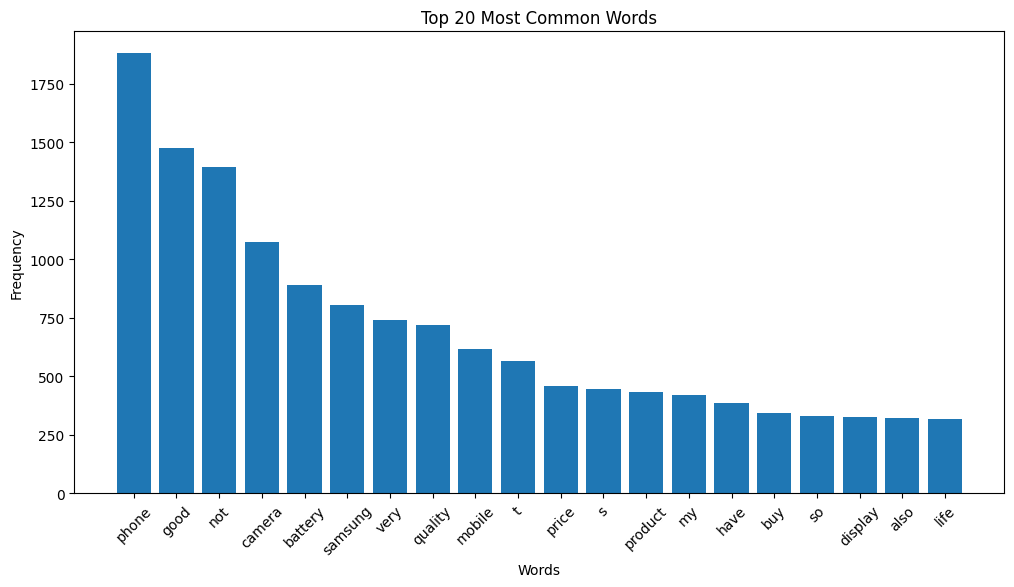

In [248]:
plt.figure(figsize=(12,6))

plt.bar(
    freq_df['Word'],
    freq_df['Frequency']
)

plt.xticks(rotation=45)

plt.title("Top 20 Most Common Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

##Interpretation:
The graph shows that words like “phone”, “camera”, “battery”, and “quality” appeared most frequently in customer reviews, indicating that users mainly discussed product features, performance, and user experience.

#Positive Review Word Analysis:
Positive Review Word Analysis was performed to identify the most frequently occurring words in positive customer reviews

In [249]:
positive_words = ' '.join(
    positive_reviews['review_text_lemmatized'].fillna('').astype(str)
).split()

positive_frequency = Counter(
    positive_words
)

positive_common = positive_frequency.most_common(20)

positive_df = pd.DataFrame(
    positive_common,
    columns=['Word', 'Frequency']
)

positive_df


,Word,Frequency
0,good,1074
1,phone,978
2,battery,596
3,camera,594
4,not,460
5,quality,346
6,price,338
7,very,338
8,samsung,326
9,s,259


#Positive Word Visualization

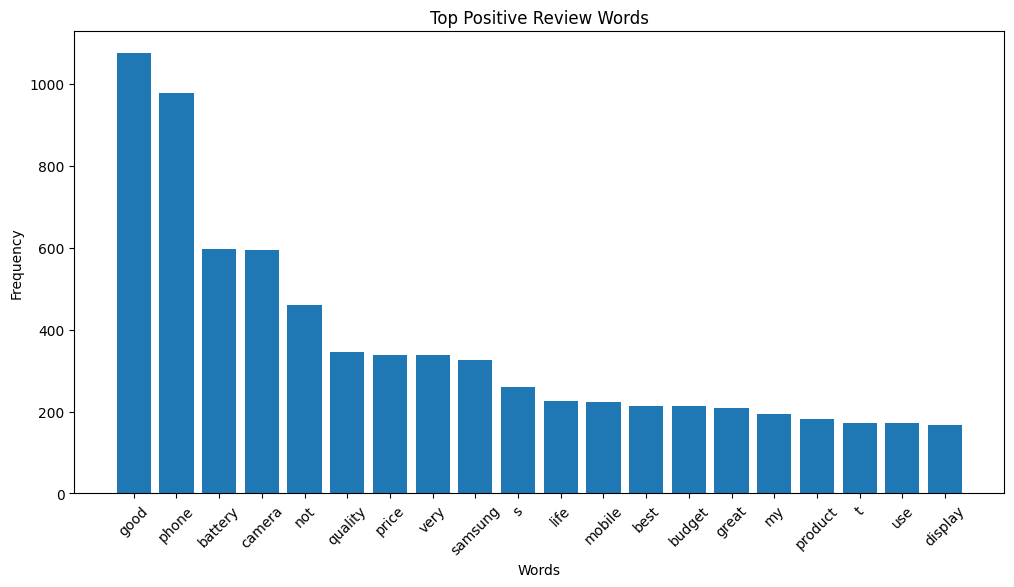

In [250]:
plt.figure(figsize=(12,6))

plt.bar(
    positive_df['Word'],
    positive_df['Frequency']
)

plt.xticks(rotation=45)

plt.title("Top Positive Review Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

##Interpretation:
Words like “good”, “camera”, “battery”, and “quality” appeared frequently in positive reviews, indicating that customers were satisfied with product features, performance, and overall user experience

In [251]:
custom_stopwords = [
    'phone',
    'mobile',
    'samsung',
    'camera',
    'product',
    'amazon',
    'buy'
]

#Negative Review Word Analysis
Negative Review Word Analysis was performed to identify the most frequently occurring words in negative customer reviews.

In [252]:
negative_words = ' '.join(
    negative_reviews['review_text_lemmatized'].fillna('').astype(str)
).split()

negative_frequency = Counter(
    negative_words
)

negative_common = negative_frequency.most_common(20)

negative_df = pd.DataFrame(
    negative_common,
    columns=['Word', 'Frequency']
)

negative_df


,Word,Frequency
0,phone,642
1,not,636
2,samsung,377
3,t,319
4,very,318
5,camera,296
6,mobile,290
7,quality,250
8,product,224
9,buy,217


#Negative Word Visualization

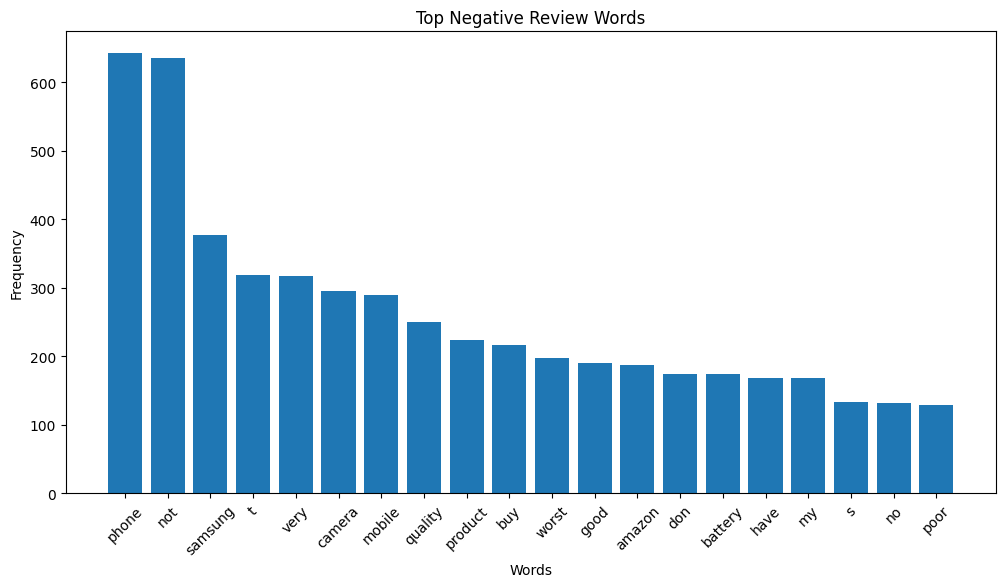

In [253]:
plt.figure(figsize=(12,6))

plt.bar(
    negative_df['Word'],
    negative_df['Frequency']
)

plt.xticks(rotation=45)

plt.title("Top Negative Review Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

##Interpretation:
Words like “worst”, “issue”, “not”, and “buy” indicate customer dissatisfaction and complaints related to product quality and performance. Product-related words such as “phone”, “camera”, and “battery” appear frequently because users discussed product features while expressing negative experiences.

#Bigram Analysis

In [254]:
bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

bigram_matrix = bigram_vectorizer.fit_transform(
    df_processed['review_text_lemmatized'].fillna('').astype(str)
)

bigram_counts = bigram_matrix.sum(axis=0)

bigram_freq = [
    (
        word,
        bigram_counts[0, idx]
    )
    for word, idx in
    bigram_vectorizer.vocabulary_.items()
]

bigram_freq = sorted(
    bigram_freq,
    key=lambda x: x[1],
    reverse=True
)

bigram_df = pd.DataFrame(
    bigram_freq,
    columns=['Bigram', 'Frequency']
)

bigram_df.head(20)


,Bigram,Frequency
0,camera quality,304
1,battery life,281
2,very good,142
3,not good,138
4,price range,124
5,good phone,121
6,good battery,100
7,budget phone,99
8,value money,95
9,don buy,92


#Bigram Visualization
Bigram Analysis was performed to identify the most frequently occurring two-word combinations in the review dataset.

Examples include:

camera quality,battery life,not good,price range




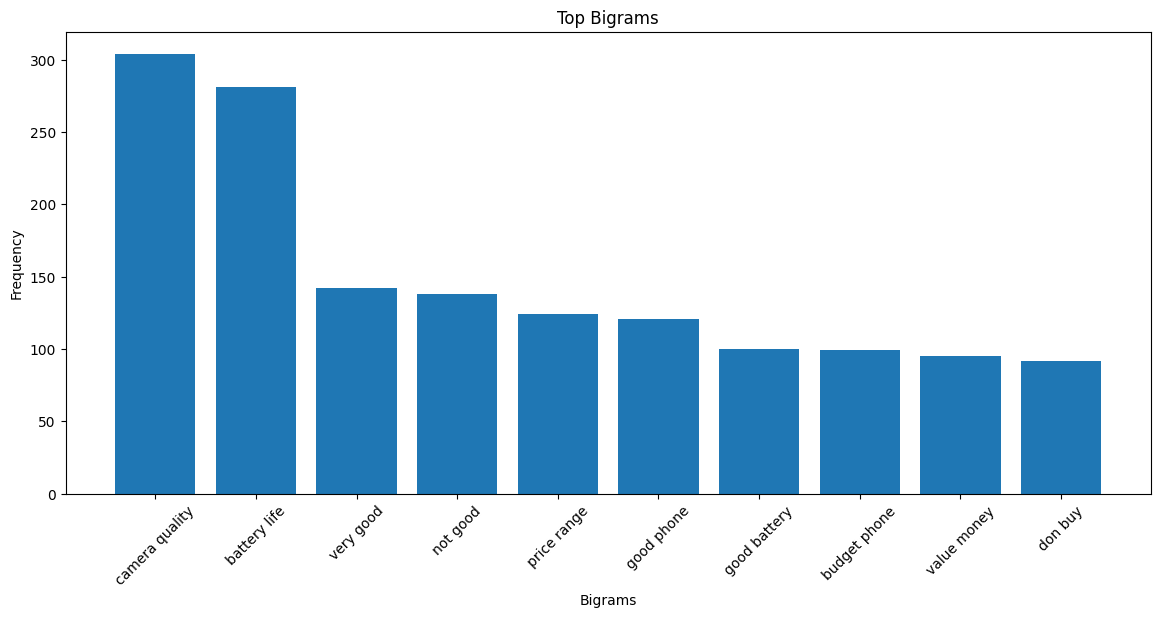

In [255]:
plt.figure(figsize=(14,6))

plt.bar(
    bigram_df['Bigram'][:10],
    bigram_df['Frequency'][:10]
)

plt.xticks(rotation=45)

plt.title("Top Bigrams")
plt.xlabel("Bigrams")
plt.ylabel("Frequency")

plt.show()

##Interpretation:
Frequent bigrams like “camera quality” and “battery life” indicate that customers mainly discussed product performance and features. Phrases such as “not good” reflect customer dissatisfaction, while “good battery” and “good camera” indicate positive user experiences. Bigram analysis helps capture meaningful review patterns and customer opinions more effectively than single-word analysis.

#Trigram Analysis

In [256]:
trigram_vectorizer = CountVectorizer(
    ngram_range=(3,3),
    max_features=20
)

trigram_matrix = trigram_vectorizer.fit_transform(
    df_processed['review_text_lemmatized'].fillna('').astype(str)
)

trigram_counts = trigram_matrix.sum(axis=0)

trigram_freq = [
    (
        word,
        trigram_counts[0, idx]
    )
    for word, idx in
    trigram_vectorizer.vocabulary_.items()
]

trigram_freq = sorted(
    trigram_freq,
    key=lambda x: x[1],
    reverse=True
)

trigram_df = pd.DataFrame(
    trigram_freq,
    columns=['Trigram', 'Frequency']
)

trigram_df.head(20)


,Trigram,Frequency
0,camera quality not,47
1,good battery life,41
2,samsung galaxy m12,38
3,media could not,34
4,could not loaded,34
5,battery life good,33
6,camera quality very,33
7,finger print reader,30
8,not up mark,29
9,quality very poor,28


#Trigram Visualization
Trigram Analysis was performed to identify the most frequent three-word combinations in the review dataset. This helps capture complete customer opinions and product-related phrases more clearly than unigram or bigram analysis.

Examples include:

battery life good,camera quality not,good battery life,camera quality poor.

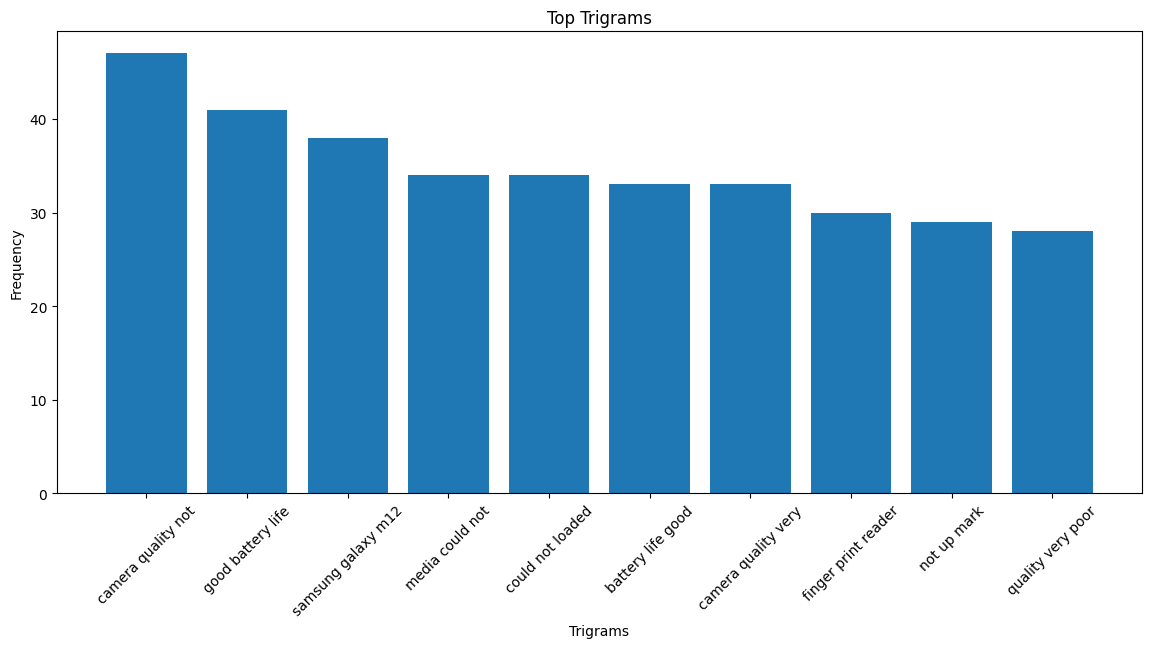

In [257]:
plt.figure(figsize=(14,6))

plt.bar(
    trigram_df['Trigram'][:10],
    trigram_df['Frequency'][:10]
)

plt.xticks(rotation=45)

plt.title("Top Trigrams")
plt.xlabel("Trigrams")
plt.ylabel("Frequency")

plt.show()

##Interpreation:
The trigram results show that customers mainly discussed battery performance, camera quality, and overall product experience. Positive phrases like “good battery life” indicate customer satisfaction, while phrases such as “camera quality not” and “camera quality poor” reflect negative feedback. The analysis helps identify detailed customer sentiments and common review patterns in the dataset

#Word Cloud Visualization
Word Cloud Visualization was created to display the most frequently occurring words in positive reviews. Larger words in the word cloud represent higher frequency in customer reviews.

#Positive Reviews Word Cloud

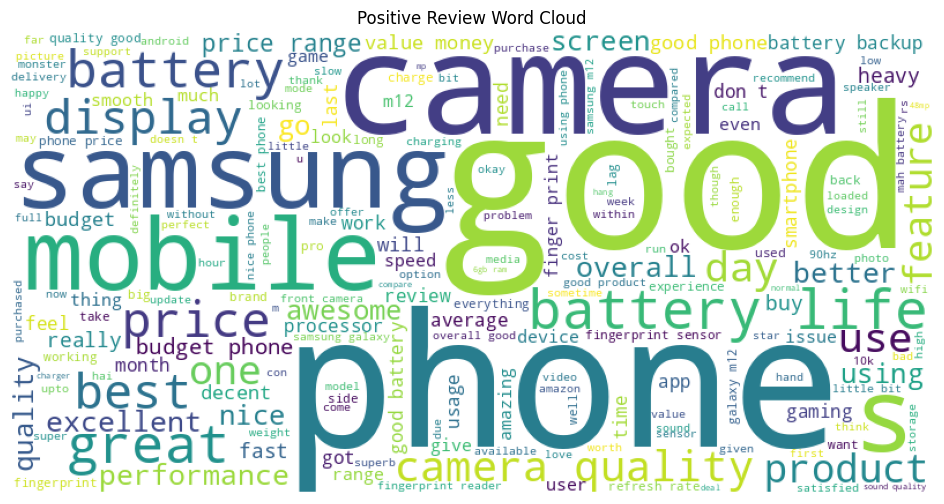

In [258]:
positive_text = ' '.join(
    positive_reviews['review_text_lemmatized'].fillna('').astype(str)
)

if WORDCLOUD_AVAILABLE and positive_text.strip():
    wordcloud_positive = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(positive_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud_positive)
    plt.axis('off')
    plt.title('Positive Review Word Cloud')
    plt.show()
else:
    positive_df.head(20).plot(kind='bar', x='Word', y='Frequency', figsize=(12, 6), legend=False)
    plt.title('Top Positive Review Words')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()


##Interpretation:
Words like “good”, “phone”, “camera”, “battery”, and “quality” appear prominently, indicating that customers were mainly satisfied with product performance, camera quality, and battery life. The visualization helps quickly identify the major positive aspects discussed by users.

#Negative Reviews Word Cloud
Negative Review Word Cloud was created to visualize the most frequently occurring words in negative customer reviews. Larger words indicate higher frequency in negative feedback.

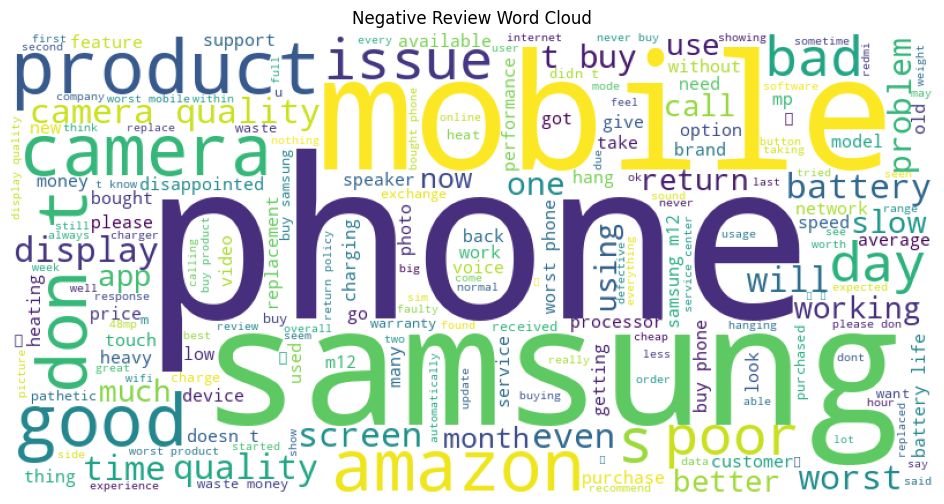

In [259]:
negative_text = ' '.join(
    negative_reviews['review_text_lemmatized'].fillna('').astype(str)
)

if WORDCLOUD_AVAILABLE and negative_text.strip():
    wordcloud_negative = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(negative_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud_negative)
    plt.axis('off')
    plt.title('Negative Review Word Cloud')
    plt.show()
else:
    negative_df.head(20).plot(kind='bar', x='Word', y='Frequency', figsize=(12, 6), legend=False)
    plt.title('Top Negative Review Words')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()


##Interpretation:
Words like “phone”, “samsung”, “screen”, “worst”, “problem”, and “bad” appear prominently, showing that customers mainly complained about product quality, screen issues, performance problems, and overall user experience. The visualization helps identify the major negative concerns discussed by customers.

#Review Length Analysis
Review Length Analysis calculates the number of words present in each processed review using the review_length feature. The histogram visualizes how review lengths are distributed across the dataset.

In [260]:
# Review length is calculated from the final cleaned combined review text.
# It does not use the raw body column.

df_processed['review_length'] = (
    df_processed['review_text_lemmatized']
    .fillna('')
    .astype(str)
    .apply(lambda x: len(x.split()))
)

df_processed[
    ['final_review_text', 'review_text_lemmatized', 'review_length', 'sentiment']
].head()


,final_review_text,review_text_lemmatized,review_length,sentiment
0,horrible product very disappointed with the ov...,horrible product very disappointed overall per...,7,negative
1,camera quality is not like 48 megapixel camera...,camera quality not like 48 megapixel camera qu...,9,neutral
2,overall got the mobile on the launch date batt...,overall got mobile launch date battery must ap...,50,positive
3,a big no from me 1 it doesn t work with 5 0ghz...,big no me 1 doesn t work 5 0ghz wifi frequency...,60,negative
4,put your money somewhere else not worth buying...,put your money somewhere else not worth buying...,32,negative


#Review Length Distribution

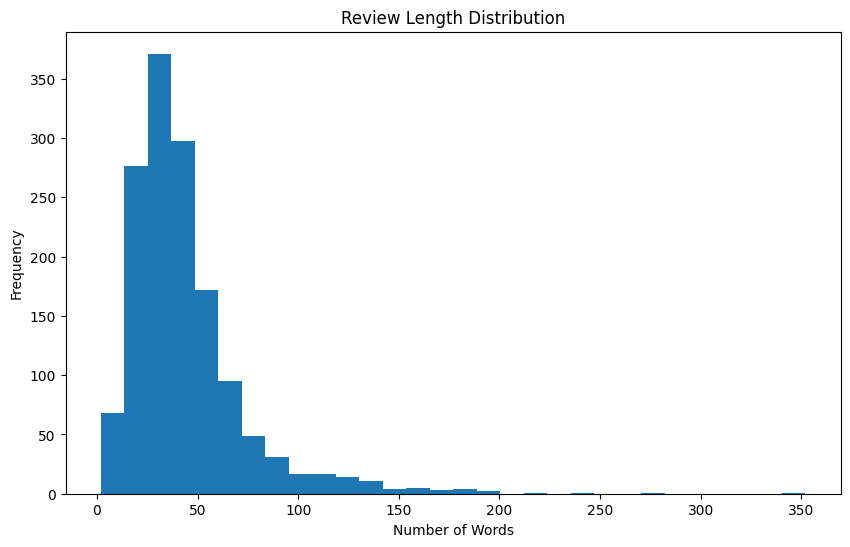

In [261]:
plt.figure(figsize=(10,6))

plt.hist(
    df_processed['review_length'],
    bins=30
)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

##Interpretation:
Most reviews contain a small to medium number of words, while only a few reviews are very long. This indicates that customers generally provide short and concise feedback, with some users giving detailed explanations about their experience.

#Review Pattern Analysis
Review Pattern Analysis calculates the average review length for each sentiment category (positive, neutral, and negative). The bar chart compares the average number of words used in different types of reviews.

In [262]:
review_pattern = df_processed.groupby(
    'sentiment'
)['review_length'].mean()

print(review_pattern)

sentiment
negative    44.826172
neutral     46.386935
positive    42.323731
Name: review_length, dtype: float64


#Review Pattern Visualization

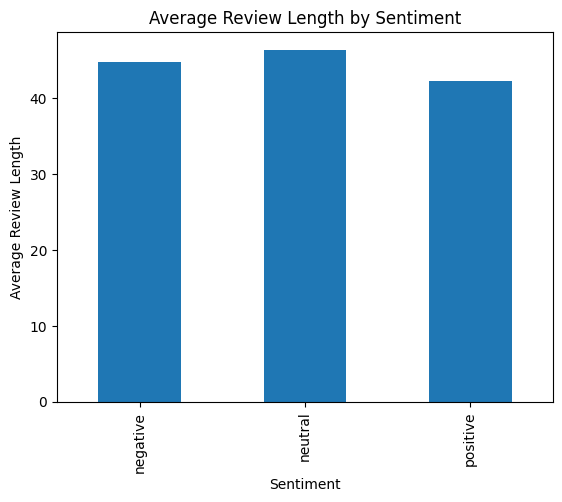

In [263]:
review_pattern.plot(
    kind='bar'
)

plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Review Length")

plt.show()

##Interpretation:
Neutral reviews have slightly higher average review lengths compared to positive and negative reviews. This indicates that neutral reviewers tend to provide more detailed explanations, while positive and negative reviews are comparatively shorter and more direct.

In [264]:
df_processed.to_csv(
    "member5_word_analysis_report.csv",
    index=False
)

print("Member 5 Report Saved Successfully")

Member 5 Report Saved Successfully


#Member 6 — Outlier Detection, Modeling Strategy
##Objectives:
* Outlier Detection
* Modeling Strategy Analysis
* Feature Extraction Preparation
* Final Insights & Documentation

#Outlier Detection
##Detect Empty or Very Short Cleaned Reviews
This step checks the **final cleaned review text**, not the raw body column. Very short reviews can still be valid sentiment reviews, so they are only flagged for review instead of being removed automatically.


In [265]:
# Member 6: Short Review Detection

df_processed['review_length'] = df_processed['final_review_text'].fillna('').apply(lambda x: len(str(x).split()))

short_reviews = df_processed[df_processed['review_length'] < 3]

print("Total short reviews:", short_reviews.shape[0])

short_reviews[['final_review_text', 'review_length', 'sentiment']].head()

Total short reviews: 2


,final_review_text,review_length,sentiment
299,prepared good,2,negative
1106,good like,2,positive


##Interpretation:
The analysis checks very short reviews using the cleaned combined review text (`final_review_text`). These reviews are not automatically removed because short reviews like “good”, “dislike”, or “hitting issue” can still carry useful sentiment. They are only flagged for review.


#Detect Repeated Text Reviews
##Function to detect repeated words



In [266]:
def repeated_text_detection(text):

    words = str(text).split()

    if len(set(words)) <= 2 and len(words) > 3:
        return "Repeated"

    return "Normal"

df_processed['repeated_text'] = (
    df_processed['body_text_lemmatized']
    .apply(repeated_text_detection)
)

print(
    df_processed['repeated_text']
    .value_counts()
)

repeated_text
Normal    1440
Name: count, dtype: int64


##Interpretation:
The analysis identified whether reviews contain spam-like repetitive text patterns. Most reviews were classified as “Normal”, indicating that the dataset contains fewer repeated or low-quality spam reviews.

##Detect Spam Reviews
This step detects duplicate or spam-like reviews by checking whether the same review text appears multiple times in the dataset.

In [267]:
# Detect duplicate/spam-like reviews

spam_reviews = df_processed[
    df_processed['body']
    .duplicated(keep=False)
]

print("Possible Spam Reviews:")
print(spam_reviews.shape[0])

Possible Spam Reviews:
0


##Interpretation:
The analysis found 0 possible spam reviews, indicating that the dataset does not contain duplicate review texts and the review data is mostly genuine and unique.

##Detect Noisy Multilingual Content
This analysis checks whether reviews contain mixed languages such as English with Telugu or Tamil characters. It helps identify noisy multilingual content in the dataset.

In [268]:
# Detect reviews containing multiple scripts

def noisy_multilingual(text):
    text = '' if pd.isna(text) else str(text)

    has_english = any(ord(c) < 128 and c.isalpha() for c in text)
    has_devanagari = any('\u0900' <= c <= '\u097F' for c in text)
    has_telugu = any('\u0C00' <= c <= '\u0C7F' for c in text)
    has_tamil = any('\u0B80' <= c <= '\u0BFF' for c in text)

    if has_english and (has_devanagari or has_telugu or has_tamil):
        return 'Mixed'

    return 'Single'

df_processed['multilingual_type'] = df_processed['body_cleaned'].apply(noisy_multilingual)

print(df_processed['multilingual_type'].value_counts())

multilingual_type
Single    1431
Mixed        9
Name: count, dtype: int64


##Interpretation:
The result shows that all 1440 reviews were classified as “Single” language reviews. This indicates that the dataset is clean and does not contain noisy mixed-language text, making it suitable for NLP preprocessing and modeling

#Feature Extraction Preparation
##Bag of Words
This step prepares text data using the Bag of Words (BoW) technique, where each review is converted into numerical word-frequency vectors using CountVectorizer

In [269]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    max_features=5000
)

bow_features = bow_vectorizer.fit_transform(
    df_processed['body_text_lemmatized'].fillna('').astype(str)
)

print("Bag of Words Shape:")
print(bow_features.shape)


Bag of Words Shape:
(1440, 5000)


##Interpretation:
The generated feature matrix size is (1440, 5000), meaning:

* 1440 reviews were processed
* 5000 important words/features were extracted

##TF-IDF
This step uses the TF-IDF (Term Frequency–Inverse Document Frequency) technique to convert text reviews into numerical feature vectors by giving more importance to meaningful and unique words.

In [270]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

tfidf_features = tfidf_vectorizer.fit_transform(
    df_processed['body_text_lemmatized'].fillna('').astype(str)
)

print("TF-IDF Shape:")
print(tfidf_features.shape)

TF-IDF Shape:
(1440, 5000)


##Interpretation:
The TF-IDF feature matrix size is (1440, 5000), meaning:

* 1440 reviews were transformed.
* 5000 important weighted features were extracted.

TF-IDF helps improve sentiment analysis performance by reducing the impact of very common words and highlighting informative terms.

#Final Insights & Documentation
##Sentiment Distribution

In [271]:
sentiment_summary = (
    df_processed['sentiment']
    .value_counts()
)

print(sentiment_summary)

sentiment
positive    729
negative    512
neutral     199
Name: count, dtype: int64


##Final Dataset Information

In [272]:
print("Final Dataset Shape:")
print(df_processed.shape)

print("\nFinal Columns:")
print(df_processed.columns)

Final Dataset Shape:
(1440, 25)

Final Columns:
Index(['title', 'rating', 'body', 'clean_title', 'clean_body', 'review_text',
       'title_cleaned', 'body_cleaned', 'final_review_text', 'sentiment',
       'title_tokens', 'body_tokens', 'review_tokens', 'title_tokens_cleaned',
       'body_tokens_cleaned', 'review_tokens_cleaned',
       'title_tokens_lemmatized', 'body_tokens_lemmatized',
       'review_tokens_lemmatized', 'title_text_lemmatized',
       'body_text_lemmatized', 'review_text_lemmatized', 'review_length',
       'repeated_text', 'multilingual_type'],
      dtype='object')


##Save Final Processed Dataset

In [273]:
# Save final cleaned dataset

df_processed.to_csv("final_sentiment_dataset.csv", index=False)

print("Final dataset saved successfully")
print("Final shape:", df_processed.shape)

Final dataset saved successfully
Final shape: (1440, 25)


#Support Vector Machine(SVM):
As we are dealing with Classification type of data ,svm is used.

-->it works based on concept of finding a hyperplane that separates the data into different classes.

--> if the data is linearly seperable ,svm finds a hyperplane that maximizes the margin between the closest points of different classes.These closest points are called support vectors.

##Import Libraries

In [274]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import GridSearchCV

import seaborn as sns
import matplotlib.pyplot as plt

##Define Features and Target

In [275]:
X = tfidf_features
y = df_processed['sentiment']
print("Input feature selected: TF-IDF Features")

print("Target output selected: sentiment")

print("Input shape:", X.shape)

print("Target shape:", y.shape)

print("\nSentiment Distribution:")

print(y.value_counts())

Input feature selected: TF-IDF Features
Target output selected: sentiment
Input shape: (1440, 5000)
Target shape: (1440,)

Sentiment Distribution:
sentiment
positive    729
negative    512
neutral     199
Name: count, dtype: int64


X contains TF-IDF numerical vectors,
y contains sentiment labels

##Train Test Split

In [276]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train-test split completed.")
print("Training text shape:", X_train.shape)
print("Testing text shape:", X_test.shape)

print("Training sentiment distribution:")
print(y_train.value_counts())

print("Testing sentiment distribution:")
print(y_test.value_counts())

Train-test split completed.
Training text shape: (1152, 5000)
Testing text shape: (288, 5000)
Training sentiment distribution:
sentiment
positive    583
negative    410
neutral     159
Name: count, dtype: int64
Testing sentiment distribution:
sentiment
positive    146
negative    102
neutral      40
Name: count, dtype: int64


Dataset split into:
80% training data,
20% testing data,
stratify=y maintains class balance

##Build Linear SVM Model

In [277]:
svm_model = SVC(
    kernel='linear',
    C=1
)

linear kernel is best for TF-IDF text data,
C=1 balances margin and classification errors

##Train the Model

In [278]:
svm_model.fit(X_train, y_train)

SVC(C=1, kernel='linear')

The model learns patterns from training reviews.

##Make Predictions

In [279]:
y_pred = svm_model.predict(X_test)

#Model Evaluation

##Accuracy Score

In [280]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7916666666666666


Accuracy measures overall correct predictions.

Accuracy=Correct Predictions/Total Predictions

##Classification Report

In [281]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.76      0.87      0.81       102
     neutral       0.83      0.12      0.22        40
    positive       0.81      0.92      0.86       146

    accuracy                           0.79       288
   macro avg       0.80      0.64      0.63       288
weighted avg       0.80      0.79      0.75       288



##Confusion Matrix

In [282]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Labels
labels = ['Negative', 'Neutral', 'Positive']

# Convert into DataFrame
cm_df = pd.DataFrame(
    cm,
    index=[f'Actual {label}' for label in labels],
    columns=[f'Predicted {label}' for label in labels]
)

# Display Table
print(cm_df)

                 Predicted Negative  Predicted Neutral  Predicted Positive
Actual Negative                  89                  0                  13
Actual Neutral                   17                  5                  18
Actual Positive                  11                  1                 134


The confusion matrix table provides a clear comparison between actual and predicted sentiment classes. Diagonal values represent correct predictions, while off-diagonal values represent misclassifications. The model classified positive and negative reviews effectively, whereas neutral reviews were frequently misclassified due to class imbalance and overlapping sentiment patterns.

##Visualize Confusion Matrix

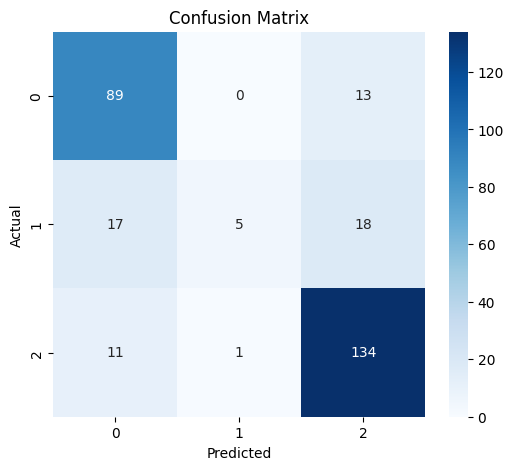

In [283]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

* The x-axis represents:Predicted Sentiment

* The y-axis represents:Actual Sentiment

* Darker color intensity indicates:Higher number of predictions

##Hyperparameter Tuning

In [284]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

##Apply GridSearchCV

In [285]:
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
             scoring='accuracy', verbose=2)

##Best Parameters

In [286]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'kernel': 'rbf'}


##Best Model

In [287]:
best_model = grid.best_estimator_

##Prediction

In [288]:
best_pred = best_model.predict(X_test)

##Accuracy

In [289]:
print("Final Accuracy:",
      accuracy_score(y_test, best_pred))

Final Accuracy: 0.7847222222222222


##Classification Report

In [290]:
print(classification_report(
    y_test,
    best_pred
))

              precision    recall  f1-score   support

    negative       0.76      0.86      0.81       102
     neutral       0.60      0.07      0.13        40
    positive       0.81      0.92      0.86       146

    accuracy                           0.78       288
   macro avg       0.72      0.62      0.60       288
weighted avg       0.76      0.78      0.74       288



In [291]:
df_processed['sentiment'].value_counts()

,count
sentiment,
positive,729
negative,512
neutral,199


#We are facing issue after tuning because of imbalaced data we have:

as you can see the count of postive,negative and neutral data

Because the data is not equally distributed.

Imbalanced data means:
One class contains significantly more samples than another class in the dataset.




##Machine learning models try to maximize overall accuracy.

Since the dataset contains more:

Positive reviews
Negative reviews

the SVM model learns these classes better.

However:

Neutral reviews are limited,
Neutral sentiment overlaps with both positive and negative sentiments

Therefore,the model struggles to learn neutral patterns properly.

So, to solve the issue of imbalance data, we have used class-weighing in which minor sample as taken into consideration and high priority is given through weights.


In [292]:
# SVM + Class-weighing

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(
    SVC(class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:",
      grid.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'C': 1, 'kernel': 'linear'}


In [293]:
from sklearn.metrics import accuracy_score, classification_report

# Get the best model from the GridSearchCV
best_model_balanced = grid.best_estimator_

# Make predictions using the best balanced model
y_pred_balanced = best_model_balanced.predict(X_test)

# Accuracy
print("Accuracy:",
      accuracy_score(y_test, y_pred_balanced))

# Classification Report
print(classification_report(
    y_test,
    y_pred_balanced
))

Accuracy: 0.71875
              precision    recall  f1-score   support

    negative       0.76      0.79      0.78       102
     neutral       0.23      0.25      0.24        40
    positive       0.84      0.79      0.82       146

    accuracy                           0.72       288
   macro avg       0.61      0.61      0.61       288
weighted avg       0.73      0.72      0.72       288



In [294]:
  # SVM + Class Weighting + Hyperparameter Tuning

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Parameter Grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# GridSearchCV
grid = GridSearchCV(
    SVC(class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=2,
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:")
print(grid.best_params_)

# Best Model
best_model_balanced = grid.best_estimator_

# Predictions
best_pred_balanced = best_model_balanced.predict(X_test)

# Accuracy
print("\nAccuracy:")
print(accuracy_score(y_test, best_pred_balanced))

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    best_pred_balanced
))

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    best_pred_balanced
)

print("\nConfusion Matrix:")
print(cm)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters:
{'C': 1, 'kernel': 'linear'}

Accuracy:
0.71875

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.79      0.78       102
     neutral       0.23      0.25      0.24        40
    positive       0.84      0.79      0.82       146

    accuracy                           0.72       288
   macro avg       0.61      0.61      0.61       288
weighted avg       0.73      0.72      0.72       288


Confusion Matrix:
[[ 81  14   7]
 [ 15  10  15]
 [ 10  20 116]]


In [295]:
# =========================================================
# RECALL AND F1-SCORE COMPARISON
# BEFORE vs AFTER HYPERPARAMETER TUNING
# =========================================================

from sklearn.metrics import classification_report
import pandas as pd

# ---------------------------------------------------------
# ORIGINAL MODEL REPORT
# ---------------------------------------------------------

original_report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

original_df = pd.DataFrame(original_report).transpose()


# ---------------------------------------------------------
# TUNED MODEL REPORT
# ---------------------------------------------------------

tuned_report = classification_report(
    y_test,
    best_pred,
    output_dict=True
)

tuned_df = pd.DataFrame(tuned_report).transpose()


# ---------------------------------------------------------
# COMPARISON TABLE
# ---------------------------------------------------------

comparison_df = pd.DataFrame({

    'Original Recall': original_df['recall'],
    'Tuned Recall': tuned_df['recall'],

    'Original F1-Score': original_df['f1-score'],
    'Tuned F1-Score': tuned_df['f1-score']

})

print(comparison_df)

              Original Recall  Tuned Recall  Original F1-Score  Tuned F1-Score
negative             0.872549      0.862745           0.812785        0.807339
neutral              0.125000      0.075000           0.217391        0.133333
positive             0.917808      0.924658           0.861736        0.862620
accuracy             0.791667      0.784722           0.791667        0.784722
macro avg            0.638452      0.620801           0.630638        0.601098
weighted avg         0.791667      0.784722           0.754907        0.741752


##Recall measures:

How many actual sentiment samples were correctly identified by the model.

Formula:

Recall=True Positives/True Positives+False Negatives

* The original SVM model achieved higher recall for the neutral class compared to the tuned model.
* Neutral recall reduced from:
0.12 → 0.07
* This indicates that hyperparameter tuning reduced the model’s ability to correctly identify neutral reviews.

##F1-score balances:

Precision
Recall

Formula:

F1=2×
[Precision×Recall/Precision+Recall]

* The neutral class F1-score decreased after tuning:
0.22 → 0.13
* This shows that the tuned model produced poorer balanced classification performance for neutral reviews.

#Comparison between Models

In [296]:
# =========================================================
# COMPARISON OF 4 SVM MODELS
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd


# =========================================================
# ACCURACY VALUES
# =========================================================

original_accuracy = accuracy_score(
    y_test,
    y_pred
)

tuned_accuracy = accuracy_score(
    y_test,
    best_pred
)

balanced_accuracy = accuracy_score(
    y_test,
    y_pred_balanced
)

balanced_tuned_accuracy = accuracy_score(
    y_test,
    best_pred_balanced
)


# =========================================================
# MODEL COMPARISON TABLE
# =========================================================

comparison_df = pd.DataFrame({

    'Metric': [

        'Accuracy',

        'Precision',

        'Recall',

        'F1-Score'

    ],

    'Original SVM': [

        round(accuracy_score(
            y_test,
            y_pred
        )*100, 2),

        round(precision_score(
            y_test,
            y_pred,
            average='weighted'
        ), 2),

        round(recall_score(
            y_test,
            y_pred,
            average='weighted'
        ), 2),

        round(f1_score(
            y_test,
            y_pred,
            average='weighted'
        ), 2)

    ],

    'Tuned SVM': [

        round(accuracy_score(
            y_test,
            best_pred
        )*100, 2),

        round(precision_score(
            y_test,
            best_pred,
            average='weighted'
        ), 2),

        round(recall_score(
            y_test,
            best_pred,
            average='weighted'
        ), 2),

        round(f1_score(
            y_test,
            best_pred,
            average='weighted'
        ), 2)

    ],

    'SVM + Class Weighting': [

        round(accuracy_score(
            y_test,
            y_pred_balanced
        )*100, 2),

        round(precision_score(
            y_test,
            y_pred_balanced,
            average='weighted'
        ), 2),

        round(recall_score(
            y_test,
            y_pred_balanced,
            average='weighted'
        ), 2),

        round(f1_score(
            y_test,
            y_pred_balanced,
            average='weighted'
        ), 2)

    ],

    'SVM + Class Weighting + Tuning': [

        round(accuracy_score(
            y_test,
            best_pred_balanced
        )*100, 2),

        round(precision_score(
            y_test,
            best_pred_balanced,
            average='weighted'
        ), 2),

        round(recall_score(
            y_test,
            best_pred_balanced,
            average='weighted'
        ), 2),

        round(f1_score(
            y_test,
            best_pred_balanced,
            average='weighted'
        ), 2)

    ]

})

print("===== COMPARISON OF 4 SVM MODELS =====\n")

print(comparison_df)


# =========================================================
# FINAL MODEL SELECTION
# =========================================================

best_accuracy = max(

    original_accuracy,

    tuned_accuracy,

    balanced_accuracy,

    balanced_tuned_accuracy

)

if best_accuracy == original_accuracy:

    final_model = svm_model

    print("Original SVM model performed better.")
    print("\nOriginal SVM model selected as FINAL MODEL.")

elif best_accuracy == tuned_accuracy:

    final_model = best_model

    print("Tuned SVM model performed better.")
    print("\nTuned SVM model selected as FINAL MODEL.")

elif best_accuracy == balanced_accuracy:

    final_model = svm_balanced

    print("\nSVM + Class Weighting model performed better.")
    print("\nSVM + Class Weighting selected as FINAL MODEL.")

else:

    final_model = best_model_balanced

    print("\nSVM + Class Weighting + Tuning model performed better.")
    print("\nSVM + Class Weighting + Tuning selected as FINAL MODEL.")

===== COMPARISON OF 4 SVM MODELS =====

      Metric  Original SVM  Tuned SVM  SVM + Class Weighting  \
0   Accuracy         79.17      78.47                  71.88   
1  Precision          0.80       0.76                   0.73   
2     Recall          0.79       0.78                   0.72   
3   F1-Score          0.75       0.74                   0.72   

   SVM + Class Weighting + Tuning  
0                           71.88  
1                            0.73  
2                            0.72  
3                            0.72  
Original SVM model performed better.

Original SVM model selected as FINAL MODEL.


Among all four models, the original Linear SVM model achieved the best overall performance with the highest accuracy, precision, recall, and F1-score values. Hyperparameter tuning and class weighting were experimented with to improve minority class classification; however, these techniques reduced the overall performance due to dataset imbalance and overlapping sentiment patterns. Therefore, the original Linear SVM model was selected as the final model for sentiment analysis because it provided the most stable and accurate classification results.The original Linear SVM model achieved an accuracy of 79.17%, while the tuned SVM model achieved an accuracy of 78.47%. Since the original model performed slightly better and provided more stable classification performance, it was selected as the final model for sentiment analysis.

In [297]:
# =========================================================
# TEST ORIGINAL SVM MODEL WITH CUSTOM REVIEWS
# =========================================================

sample_reviews = [

    "This phone is very good",

    "Battery backup is amazing",

    "Worst product ever",

    "Camera quality is very bad",

    "Phone is okay",

    "Product is average"

]

# Convert sample reviews into TF-IDF vectors
sample_reviews_tfidf = tfidf_vectorizer.transform(sample_reviews)

# Predict sentiments using ORIGINAL SVM model
sample_predictions = svm_model.predict(sample_reviews_tfidf)

# Display predictions
for review, prediction in zip(sample_reviews, sample_predictions):

    print("Review:", review)

    print("Predicted Sentiment:", prediction)

    print("-" * 50)

Review: This phone is very good
Predicted Sentiment: positive
--------------------------------------------------
Review: Battery backup is amazing
Predicted Sentiment: positive
--------------------------------------------------
Review: Worst product ever
Predicted Sentiment: negative
--------------------------------------------------
Review: Camera quality is very bad
Predicted Sentiment: negative
--------------------------------------------------
Review: Phone is okay
Predicted Sentiment: positive
--------------------------------------------------
Review: Product is average
Predicted Sentiment: neutral
--------------------------------------------------


In [298]:
# =========================================================
# TEST ORIGINAL SVM MODEL WITH USER INPUT
# =========================================================

# Take custom review input from user
custom_review = input("Enter a review: ")

# Convert review into TF-IDF vector
custom_review_tfidf = tfidf_vectorizer.transform(
    [custom_review]
)

# Predict sentiment using ORIGINAL SVM model
custom_prediction = svm_model.predict(
    custom_review_tfidf
)

# Display prediction
print("Predicted Sentiment:",
      custom_prediction[0])

Enter a review: Average performance and decent quality
Predicted Sentiment: neutral


#Save the Final Model

In [299]:
# =========================================================
# SAVE FINAL SVM MODEL AND TF-IDF VECTORIZER
# =========================================================

import joblib

# Save Final Selected SVM Model
joblib.dump(
    final_model,
    'final_svm_model.pkl'
)

# Save TF-IDF Vectorizer
joblib.dump(
    tfidf_vectorizer,
    'tfidf_vectorizer.pkl'
)

print("Final SVM model saved successfully.")

print("TF-IDF vectorizer saved successfully.")

Final SVM model saved successfully.
TF-IDF vectorizer saved successfully.
